In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
import sklearn.preprocessing
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import math

In [5]:
df = pd.read_parquet(f'../Data/final_improved_dataset_reduced.pqt')
df.head(3)

,item_id,store_id,units_sold,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,item_category,day_of_week,...,month,year,state_cpi,state_cpi_mom_delta,state_ur,state_ur_mom_delta,state_gas_price,state_gas_wow_delta,consumer_sentiment,state_snap
0,1437,0,0,30,4,4,2,0.459961,1,5,...,1,2011,237.125,0.0,12.101562,0.0,3.292969,0.0,74.1875,0
1,428,6,0,30,4,4,2,1.879883,0,5,...,1,2011,200.250,0.0,8.203125,0.0,2.974609,0.0,74.1875,0
2,427,6,0,30,4,4,2,1.879883,0,5,...,1,2011,200.250,0.0,8.203125,0.0,2.974609,0.0,74.1875,0


In [13]:
print(df['units_sold'].mean())
print(df['units_sold'].max())

1.1308878055473464
763


In [ ]:
item_cat = df.loc[df['units_sold'].idxmax()]
print(item_cat)

item_id                 702.000000
store_id                  2.000000
units_sold              763.000000
event_name_1             30.000000
event_type_1              4.000000
event_name_2              4.000000
event_type_2              2.000000
sell_price                1.000000
item_category             0.000000
day_of_week               5.000000
day_of_month             14.000000
month                     9.000000
year                   2013.000000
state_cpi               247.000000
state_cpi_mom_delta       0.000000
state_ur                  8.796875
state_ur_mom_delta        0.000000
state_gas_price           3.796875
state_gas_wow_delta       0.000000
consumer_sentiment       77.500000
state_snap                0.000000
Name: 29268031, dtype: float64


In [20]:
non_zero_cpi_deltas = df[df['state_cpi_mom_delta'] > 0]
print(non_zero_cpi_deltas['state_cpi_mom_delta'].count())

1320


In [ ]:
units_sold = df['units_sold']
units_sold.head()
print(df['units_sold'].count())

unique_items = df['item_id'].unique()
print(unique_items.shape[0])

59181090
3049


In [ ]:
print(df['year'].unique())
print(df['year'].nunique())

[2011 2012 2013 2014 2015 2016]
6


In [60]:
df_new = df.groupby('item_id')['units_sold'].sum().reset_index()
df_new.head()

,item_id,units_sold
0,0,12404
1,1,7465
2,2,13578
3,3,132251
4,4,23419


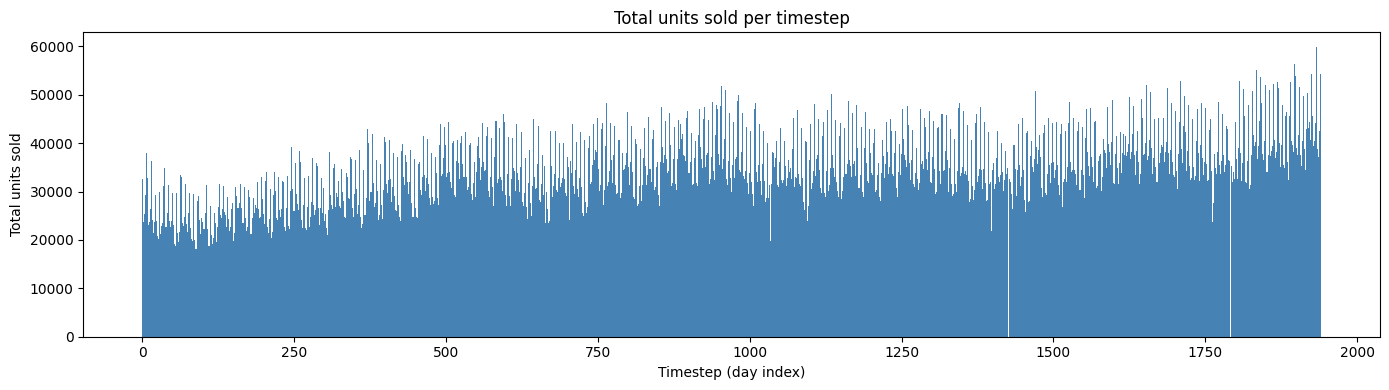

In [124]:
daily_sales = df.groupby(['year', 'month', 'day_of_month'])['units_sold'].sum().reset_index()
daily_sales = daily_sales.sort_values(['year', 'month', 'day_of_month']).reset_index(drop=True)
daily_sales['timestep'] = daily_sales.index
daily_sales['date'] = pd.to_datetime(daily_sales[['year', 'month', 'day_of_month']].rename(columns={'day_of_month':'day'}))
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_sales['timestep'], daily_sales['units_sold'], width=1.0, color='steelblue', edgecolor='none')

ax.set_xlabel('Timestep (day index)')
ax.set_ylabel('Total units sold')
ax.set_title('Total units sold per timestep')
plt.tight_layout()
plt.show()

In [125]:
lowest_sales_day = daily_sales[daily_sales['units_sold'] < 5000]
lowest_sales_day.head()


,year,month,day_of_month,units_sold,timestep,date
330,2011,12,25,13,330,2011-12-25
696,2012,12,25,11,696,2012-12-25
1061,2013,12,25,20,1061,2013-12-25
1426,2014,12,25,20,1426,2014-12-25
1791,2015,12,25,14,1791,2015-12-25


593
199199


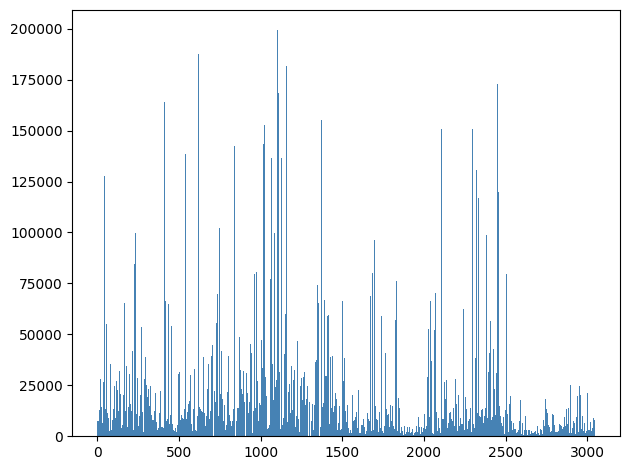

In [93]:
# Total units sold per item_id
total_sales_per_item = df.groupby('item_id')['units_sold'].sum()
total_sales_per_item = total_sales_per_item[total_sales_per_item <= 200000]
print(total_sales_per_item.min())
print(total_sales_per_item.max())

fig, ax = plt.subplots()
ax.bar(total_sales_per_item.index, total_sales_per_item, width=1.0, color='steelblue', edgecolor='none')

plt.tight_layout()
plt.show()

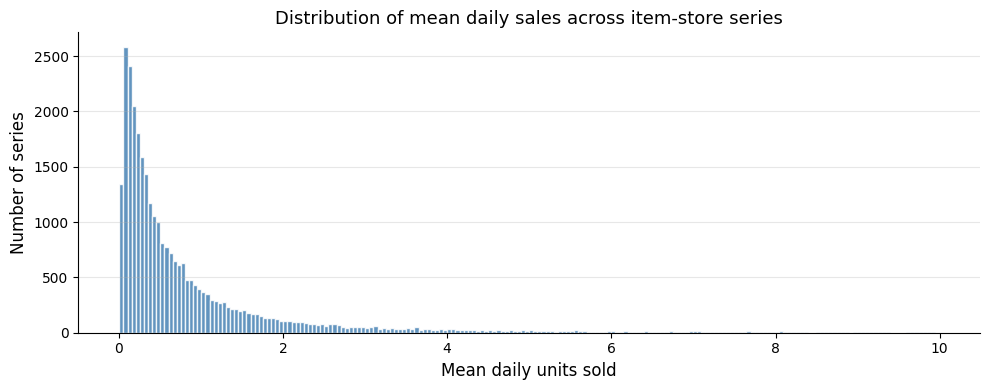

Median mean daily sales: 0.44
Series with mean < 1 unit/day: 22370
74.26219168077549
71


In [ ]:
# Sales per series
mean_sales_per_series = df.groupby(['item_id', 'store_id'])['units_sold'].mean()

mean_sales_per_series = mean_sales_per_series[mean_sales_per_series <= 10]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mean_sales_per_series, bins=200, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean daily units sold', fontsize=12)
ax.set_ylabel('Number of series', fontsize=12)
ax.set_title('Distribution of mean daily sales across item-store series', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median mean daily sales: {mean_sales_per_series.median():.2f}")
print(f"Series with mean < 1 unit/day: {(mean_sales_per_series < 1).sum()}")
print((mean_sales_per_series < 1).mean() * 100)
print((mean_sales_per_series[mean_sales_per_series > 9]).count())

C:\Users\juliub\AppData\Local\Temp\ipykernel_29148\828879703.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'FOODS' has dtype incompatible with int16, please explicitly cast to a compatible dtype first.
  daily_item_cat_sales.loc[daily_item_cat_sales['item_category'] == 0, 'item_category'] = 'FOODS'


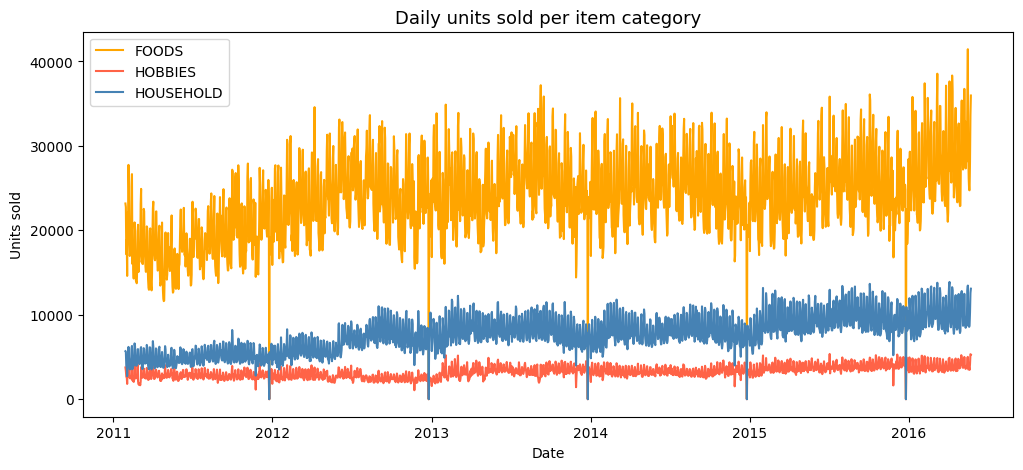

In [260]:
# Daily sales per item category
item_cats = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
daily_item_cat_sales = df.groupby(['item_category', 'year', 'month', 'day_of_month'])['units_sold'].sum().reset_index()
daily_item_cat_sales['date'] = pd.to_datetime(daily_item_cat_sales[['year', 'month', 'day_of_month']].rename(columns={'day_of_month':'day'}))
daily_item_cat_sales = daily_item_cat_sales.drop(columns=['year', 'month', 'day_of_month'])

daily_item_cat_sales.loc[daily_item_cat_sales['item_category'] == 0, 'item_category'] = 'FOODS'
daily_item_cat_sales.loc[daily_item_cat_sales['item_category'] == 1, 'item_category'] = 'HOBBIES'
daily_item_cat_sales.loc[daily_item_cat_sales['item_category'] == 2, 'item_category'] = 'HOUSEHOLD'

data = daily_item_cat_sales

foods_sales = data.loc[data['item_category'] == 'FOODS', 'units_sold']
hobbies_sales = data.loc[data['item_category'] == 'HOBBIES', 'units_sold']
household_sales = data.loc[data['item_category'] == 'HOUSEHOLD', 'units_sold']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data['date'].unique(), foods_sales, color='orange', label='FOODS')
ax.plot(data['date'].unique(), hobbies_sales, color='tomato', label='HOBBIES')
ax.plot(data['date'].unique(), household_sales, color='steelblue', label='HOUSEHOLD')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Units sold', fontsize=10)
ax.set_title('Daily units sold per item category', fontsize=13)
plt.legend(loc='upper left')
plt.show()